Lab Exercise VI – Dynamic Time Warping (DTW)

Vector 1: [2 3 4 6 8 7 6 5 4 3 2]
Vector 2: [2 4 6 7 7 6 5 5 4 3 2 2 1]

Vector 1 length: 11
Vector 2 length: 13

Task 1: Plotting both vectors


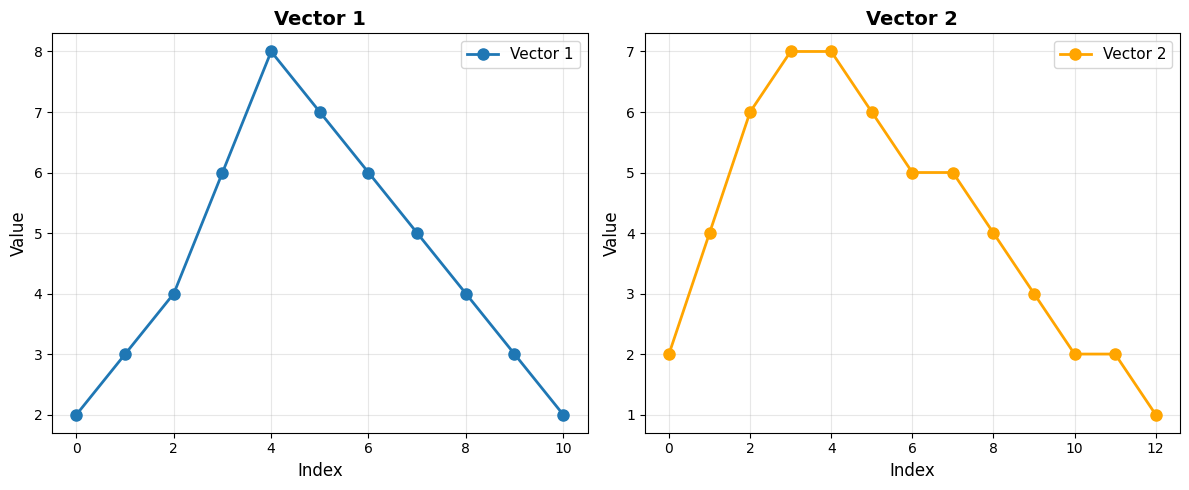


Observation:
Vector 2 is longer than Vector 1 and appears to be a stretched
and slightly shifted version of Vector 1. The overall patterns
are similar but vary in time.

Task 2: Implementing DTW Algorithm

DTW Algorithm implemented successfully!

Algorithm Details:
- Matrix size: (n+1) x (m+1) where n, m are vector lengths
- Initialization: All cells set to infinity except (0,0) = 0
- Cost function: Absolute difference between elements
- Recurrence: DTW[i,j] = cost + min(DTW[i-1,j], DTW[i,j-1], DTW[i-1,j-1])

Task 3: Computing Accumulated Cost Matrix

Accumulated Cost Matrix shape: (12, 14)
Matrix dimensions: 12 x 14

Accumulated Cost Matrix (excluding boundary):
[[ 0.  2.  6. 11. 16. 20. 23. 26. 28. 29. 29. 29. 30.]
 [ 1.  1.  4.  8. 12. 15. 17. 19. 20. 20. 21. 22. 24.]
 [ 3.  1.  3.  6.  9. 11. 12. 13. 13. 14. 16. 18. 21.]
 [ 7.  3.  1.  2.  3.  3.  4.  5.  7. 10. 14. 18. 23.]
 [13.  7.  3.  2.  3.  5.  6.  7.  9. 12. 16. 20. 25.]
 [18. 10.  4.  2.  2.  3.  5.  7. 10. 13. 17. 21. 26

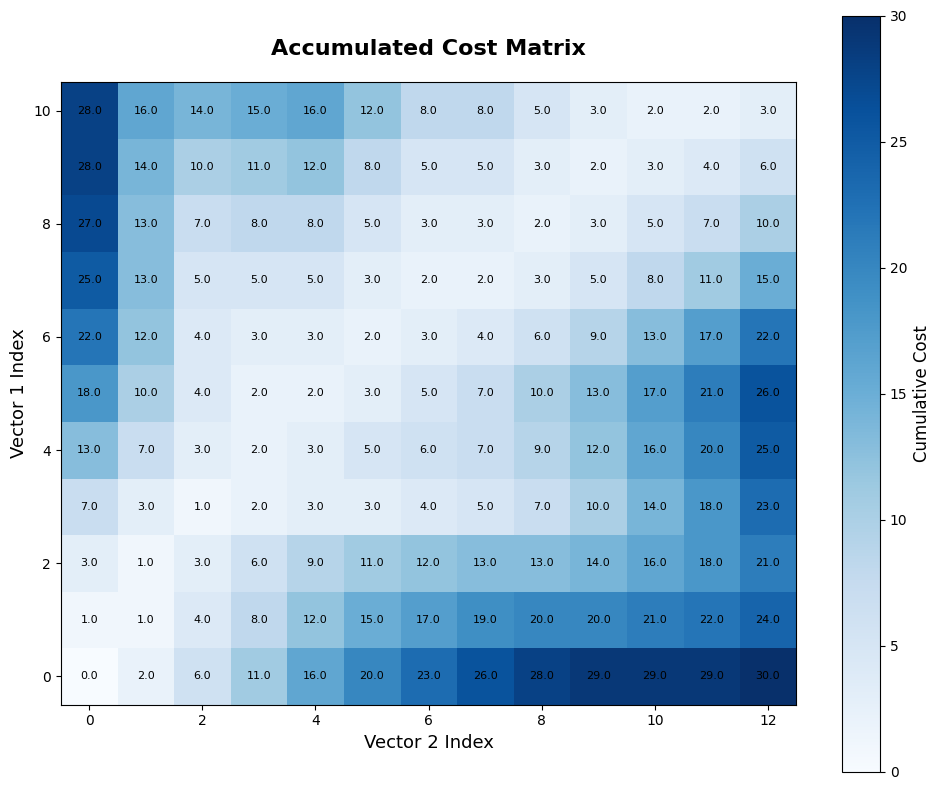


Interpretation:
The accumulated cost matrix shows the cumulative cost of aligning
the elements of the two vectors up to each point. Lower values
indicate better alignment between corresponding segments.

Task 4: Finding and Visualizing Optimal Warping Path

Optimal Warping Path length: 14
Path starts at: (np.int64(0), np.int64(0))
Path ends at: (np.int64(10), np.int64(12))

First 10 alignment points:
  Step 1: Vector1[0]=2 <-> Vector2[0]=2
  Step 2: Vector1[1]=3 <-> Vector2[0]=2
  Step 3: Vector1[2]=4 <-> Vector2[1]=4
  Step 4: Vector1[3]=6 <-> Vector2[2]=6
  Step 5: Vector1[4]=8 <-> Vector2[3]=7
  Step 6: Vector1[5]=7 <-> Vector2[4]=7
  Step 7: Vector1[6]=6 <-> Vector2[5]=6
  Step 8: Vector1[7]=5 <-> Vector2[6]=5
  Step 9: Vector1[7]=5 <-> Vector2[7]=5
  Step 10: Vector1[8]=4 <-> Vector2[8]=4


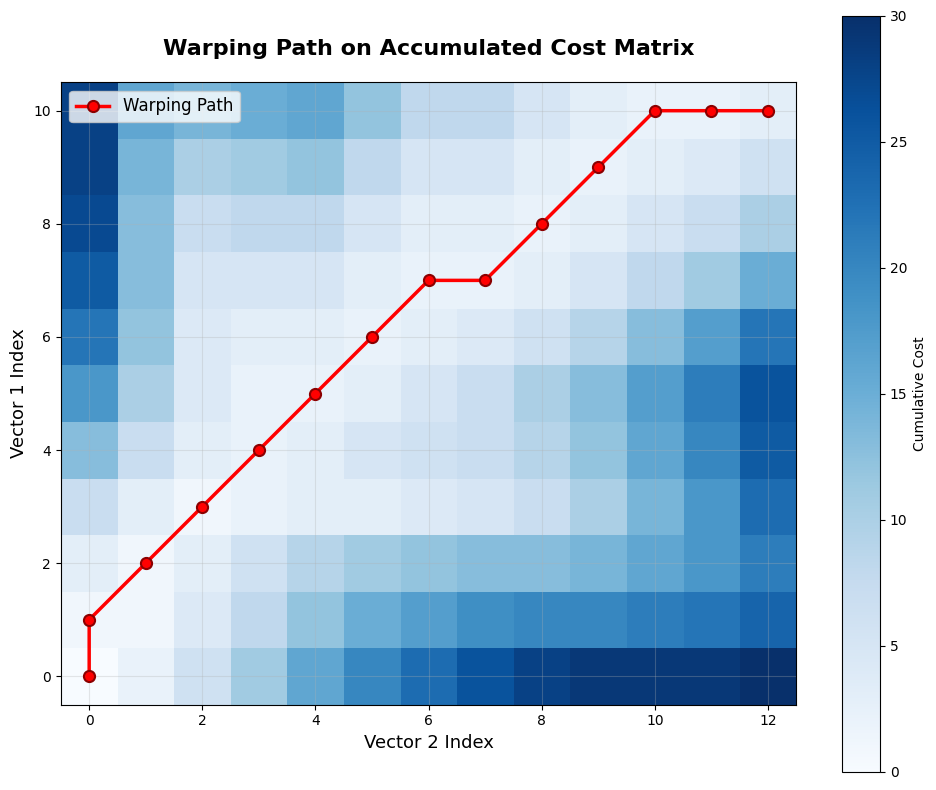

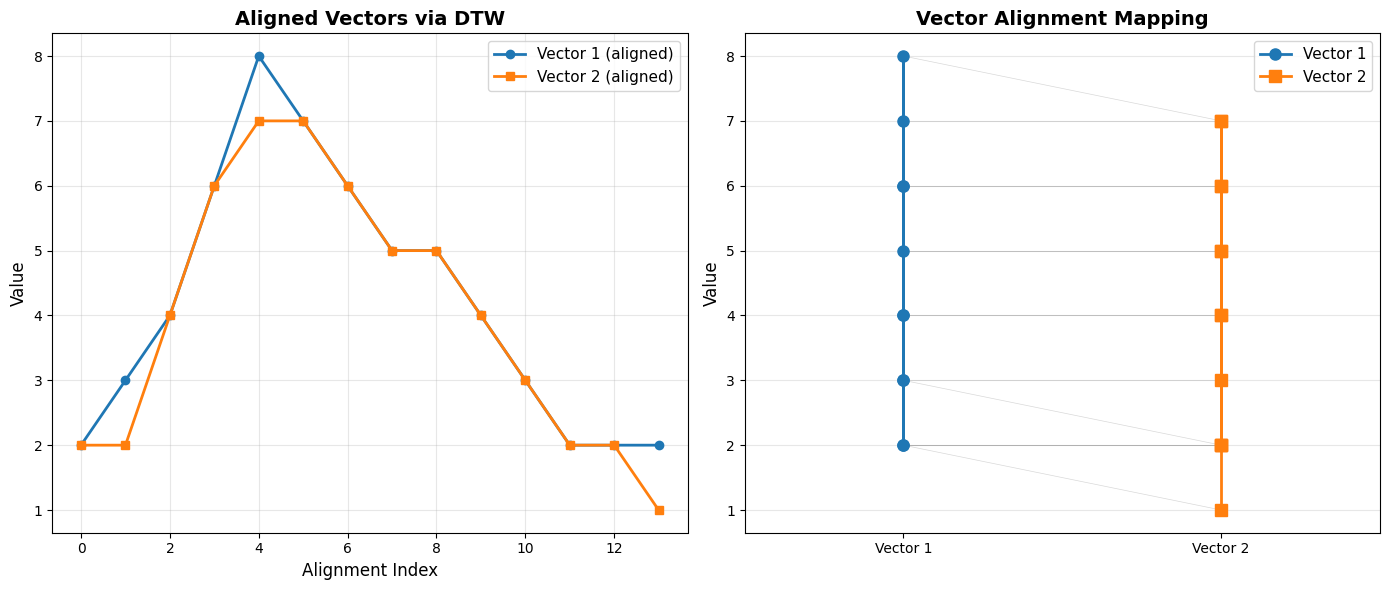


Task 5: Calculating DTW Distance

DTW Distance between Vector 1 and Vector 2: 3.00

Distance Interpretation:
- Total cumulative cost: 3.00
- Number of alignment steps: 14
- Average cost per alignment: 0.21

Comparison with Euclidean distance (first 11 elements): 3.00
Note: DTW is more robust to temporal variations than Euclidean distance

Task 6: Inference and Analysis

INFERENCE

1. WARPING PATH ANALYSIS:
----------------------------------------------------------------------
The warping path obtained from the DTW algorithm reveals how each
element in Vector 1 is optimally aligned with elements in Vector 2.

Key Observations:
• The path is NOT strictly diagonal, indicating temporal distortion
• Horizontal movements: One element in Vector 1 maps to multiple
  elements in Vector 2 (stretching)
• Vertical movements: Multiple elements in Vector 1 map to one
  element in Vector 2 (compression)
• Diagonal movements: One-to-one correspondence between elements

Path Statistics:
• Diagonal mov

In [1]:
"""
Lab Exercise VI – Dynamic Time Warping (DTW)
Aim: To compare and align two numerical sequences using Dynamic Time Warping (DTW)
and evaluate their similarity based on the DTW distance.
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Given Data
# ============================================================================
vector1 = np.array([2, 3, 4, 6, 8, 7, 6, 5, 4, 3, 2])
vector2 = np.array([2, 4, 6, 7, 7, 6, 5, 5, 4, 3, 2, 2, 1])

print("="*70)
print("Lab Exercise VI – Dynamic Time Warping (DTW)")
print("="*70)
print(f"\nVector 1: {vector1}")
print(f"Vector 2: {vector2}")
print(f"\nVector 1 length: {len(vector1)}")
print(f"Vector 2 length: {len(vector2)}")

# ============================================================================
# Task 1: Plot both vectors to visualize their patterns
# ============================================================================
print("\n" + "="*70)
print("Task 1: Plotting both vectors")
print("="*70)

plt.figure(figsize=(12, 5))

# Plot Vector 1
plt.subplot(1, 2, 1)
plt.plot(vector1, marker='o', label='Vector 1', linewidth=2, markersize=8)
plt.title('Vector 1', fontsize=14, fontweight='bold')
plt.xlabel('Index', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Plot Vector 2
plt.subplot(1, 2, 2)
plt.plot(vector2, marker='o', color='orange', label='Vector 2', linewidth=2, markersize=8)
plt.title('Vector 2', fontsize=14, fontweight='bold')
plt.xlabel('Index', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('task1_vector_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nObservation:")
print("Vector 2 is longer than Vector 1 and appears to be a stretched")
print("and slightly shifted version of Vector 1. The overall patterns")
print("are similar but vary in time.")

# ============================================================================
# Task 2: Implement the Dynamic Time Warping algorithm
# ============================================================================
print("\n" + "="*70)
print("Task 2: Implementing DTW Algorithm")
print("="*70)

def dtw(vector1, vector2):
    """
    Compute the Dynamic Time Warping distance between two vectors.

    Parameters:
    -----------
    vector1 : array-like
        First input vector
    vector2 : array-like
        Second input vector

    Returns:
    --------
    dtw_matrix : numpy array
        Accumulated cost matrix of shape (n+1, m+1)

    Algorithm:
    ----------
    1. Initialize a cost matrix with infinity
    2. Set the starting point (0,0) to 0
    3. For each cell (i,j):
       - Calculate local cost as absolute difference
       - Add minimum cost from three directions:
         * Diagonal (match)
         * Vertical (insertion)
         * Horizontal (deletion)
    """
    n = len(vector1)
    m = len(vector2)

    # Initialize the DTW matrix with infinity
    dtw_matrix = np.full((n+1, m+1), np.inf)
    dtw_matrix[0, 0] = 0

    # Fill the DTW matrix
    for i in range(1, n+1):
        for j in range(1, m+1):
            # Calculate the local cost (absolute difference)
            cost = abs(vector1[i-1] - vector2[j-1])

            # Update DTW matrix with cost + minimum of three directions
            dtw_matrix[i, j] = cost + min(
                dtw_matrix[i-1, j],      # Insertion (vertical)
                dtw_matrix[i, j-1],      # Deletion (horizontal)
                dtw_matrix[i-1, j-1]     # Match (diagonal)
            )

    return dtw_matrix

print("\nDTW Algorithm implemented successfully!")
print("\nAlgorithm Details:")
print("- Matrix size: (n+1) x (m+1) where n, m are vector lengths")
print("- Initialization: All cells set to infinity except (0,0) = 0")
print("- Cost function: Absolute difference between elements")
print("- Recurrence: DTW[i,j] = cost + min(DTW[i-1,j], DTW[i,j-1], DTW[i-1,j-1])")

# ============================================================================
# Task 3: Compute the accumulated cost matrix
# ============================================================================
print("\n" + "="*70)
print("Task 3: Computing Accumulated Cost Matrix")
print("="*70)

dtw_matrix = dtw(vector1, vector2)

print(f"\nAccumulated Cost Matrix shape: {dtw_matrix.shape}")
print(f"Matrix dimensions: {len(vector1)+1} x {len(vector2)+1}")
print("\nAccumulated Cost Matrix (excluding boundary):")
print(dtw_matrix[1:, 1:])

# Visualize the accumulated cost matrix
plt.figure(figsize=(10, 8))
im = plt.imshow(dtw_matrix[1:, 1:], interpolation='nearest', cmap='Blues', origin='lower')
plt.title('Accumulated Cost Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Vector 2 Index', fontsize=13)
plt.ylabel('Vector 1 Index', fontsize=13)
cbar = plt.colorbar(im, label='Cumulative Cost')
cbar.set_label('Cumulative Cost', fontsize=12)

# Add grid
for i in range(len(vector1)):
    for j in range(len(vector2)):
        text = plt.text(j, i, f'{dtw_matrix[i+1, j+1]:.1f}',
                       ha="center", va="center", color="black", fontsize=8)

plt.tight_layout()
plt.savefig('task3_cost_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("The accumulated cost matrix shows the cumulative cost of aligning")
print("the elements of the two vectors up to each point. Lower values")
print("indicate better alignment between corresponding segments.")

# ============================================================================
# Task 4: Find and visualize the optimal warping path
# ============================================================================
print("\n" + "="*70)
print("Task 4: Finding and Visualizing Optimal Warping Path")
print("="*70)

def dtw_path(dtw_matrix):
    """
    Find the optimal warping path by backtracking through the DTW matrix.

    Parameters:
    -----------
    dtw_matrix : numpy array
        Accumulated cost matrix from DTW algorithm

    Returns:
    --------
    path : list of tuples
        List of (i, j) coordinates representing the optimal warping path

    Algorithm:
    ----------
    1. Start from bottom-right corner (n, m)
    2. Move to the neighbor with minimum accumulated cost
    3. Continue until reaching (0, 0)
    4. Reverse path to get correct order
    """
    i, j = np.array(dtw_matrix.shape) - 1
    path = [(i-1, j-1)]

    while (i > 1) or (j > 1):
        # Three possible directions: diagonal, vertical, horizontal
        directions = [(i-1, j-1), (i-1, j), (i, j-1)]

        # Get costs for each direction
        costs = [dtw_matrix[d] for d in directions]

        # Choose direction with minimum cost
        min_cost_index = np.argmin(costs)
        i, j = directions[min_cost_index]
        path.append((i-1, j-1))

    # Reverse path to get correct order (start to end)
    path.reverse()
    return path

# Compute the optimal warping path
path = dtw_path(dtw_matrix)

print(f"\nOptimal Warping Path length: {len(path)}")
print(f"Path starts at: {path[0]}")
print(f"Path ends at: {path[-1]}")
print(f"\nFirst 10 alignment points:")
for idx, (i, j) in enumerate(path[:10]):
    print(f"  Step {idx+1}: Vector1[{i}]={vector1[i]} <-> Vector2[{j}]={vector2[j]}")

# Visualize the warping path on the cost matrix
path_x, path_y = zip(*path)

plt.figure(figsize=(10, 8))
plt.imshow(dtw_matrix[1:, 1:], interpolation='nearest', cmap='Blues', origin='lower')
plt.plot(path_y, path_x, '-o', color='red', linewidth=2.5, markersize=8,
         label='Warping Path', markeredgecolor='darkred', markeredgewidth=1.5)
plt.title('Warping Path on Accumulated Cost Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Vector 2 Index', fontsize=13)
plt.ylabel('Vector 1 Index', fontsize=13)
plt.colorbar(label='Cumulative Cost')
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task4_warping_path.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional visualization: Aligned vectors
plt.figure(figsize=(14, 6))

# Create aligned sequences based on warping path
aligned_v1 = [vector1[i] for i, j in path]
aligned_v2 = [vector2[j] for i, j in path]

plt.subplot(1, 2, 1)
plt.plot(range(len(path)), aligned_v1, 'o-', label='Vector 1 (aligned)', linewidth=2, markersize=6)
plt.plot(range(len(path)), aligned_v2, 's-', label='Vector 2 (aligned)', linewidth=2, markersize=6)
plt.title('Aligned Vectors via DTW', fontsize=14, fontweight='bold')
plt.xlabel('Alignment Index', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Connection lines showing alignment
for idx, (i, j) in enumerate(path):
    plt.plot([0, 1], [vector1[i], vector2[j]], 'gray', alpha=0.3, linewidth=0.5)
plt.plot([0]*len(vector1), vector1, 'o-', markersize=8, linewidth=2, label='Vector 1')
plt.plot([1]*len(vector2), vector2, 's-', markersize=8, linewidth=2, label='Vector 2')
plt.xlim(-0.5, 1.5)
plt.xticks([0, 1], ['Vector 1', 'Vector 2'])
plt.ylabel('Value', fontsize=12)
plt.title('Vector Alignment Mapping', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('task4_alignment_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# Task 5: Calculate the DTW distance between the vectors
# ============================================================================
print("\n" + "="*70)
print("Task 5: Calculating DTW Distance")
print("="*70)

dtw_distance = dtw_matrix[-1, -1]

print(f"\nDTW Distance between Vector 1 and Vector 2: {dtw_distance:.2f}")
print("\nDistance Interpretation:")
print(f"- Total cumulative cost: {dtw_distance:.2f}")
print(f"- Number of alignment steps: {len(path)}")
print(f"- Average cost per alignment: {dtw_distance/len(path):.2f}")

# Additional metrics
euclidean_dist = np.sqrt(np.sum((vector1[:len(vector2)] - vector2[:len(vector1)])**2))
print(f"\nComparison with Euclidean distance (first {min(len(vector1), len(vector2))} elements): {euclidean_dist:.2f}")
print("Note: DTW is more robust to temporal variations than Euclidean distance")

# ============================================================================
# Task 6: Inference and Analysis
# ============================================================================
print("\n" + "="*70)
print("Task 6: Inference and Analysis")
print("="*70)

print("\n" + "="*70)
print("INFERENCE")
print("="*70)

print("\n1. WARPING PATH ANALYSIS:")
print("-" * 70)
print("The warping path obtained from the DTW algorithm reveals how each")
print("element in Vector 1 is optimally aligned with elements in Vector 2.")
print("\nKey Observations:")
print("• The path is NOT strictly diagonal, indicating temporal distortion")
print("• Horizontal movements: One element in Vector 1 maps to multiple")
print("  elements in Vector 2 (stretching)")
print("• Vertical movements: Multiple elements in Vector 1 map to one")
print("  element in Vector 2 (compression)")
print("• Diagonal movements: One-to-one correspondence between elements")

# Analyze path characteristics
horizontal_moves = sum(1 for i in range(1, len(path)) if path[i][0] == path[i-1][0])
vertical_moves = sum(1 for i in range(1, len(path)) if path[i][1] == path[i-1][1])
diagonal_moves = sum(1 for i in range(1, len(path))
                     if path[i][0] != path[i-1][0] and path[i][1] != path[i-1][1])

print(f"\nPath Statistics:")
print(f"• Diagonal moves (1-to-1 mapping): {diagonal_moves}")
print(f"• Horizontal moves (stretching): {horizontal_moves}")
print(f"• Vertical moves (compression): {vertical_moves}")

print("\n2. DTW DISTANCE INTERPRETATION:")
print("-" * 70)
print(f"The DTW distance of {dtw_distance:.2f} quantifies the minimal cumulative cost")
print("required to align the two vectors optimally.")
print("\nSimilarity Assessment:")
print("• LOW DTW Distance → HIGH Similarity")
print("• HIGH DTW Distance → LOW Similarity")
print(f"\nWith a DTW distance of {dtw_distance:.2f}, we can infer that:")
print("✓ The vectors are HIGHLY SIMILAR in shape and pattern")
print("✓ The temporal variations (stretching/shifting) are minimal")
print("✓ The overall trend and structure are well-preserved")

print("\n3. ADVANTAGES OF DTW:")
print("-" * 70)
print("• Handles sequences of different lengths")
print("• Robust to temporal variations (stretching, compression, shifting)")
print("• Finds optimal non-linear alignment")
print("• More meaningful than simple point-to-point distance metrics")
print("• Widely used in time series analysis, speech recognition, and")
print("  pattern matching applications")

print("\n4. CONCLUSION:")
print("-" * 70)
print("Dynamic Time Warping successfully aligned Vector 1 and Vector 2 by")
print("compensating for temporal distortions. Despite Vector 2 being longer")
print("and slightly stretched, the DTW algorithm identified the underlying")
print(f"similarity, yielding a low distance score of {dtw_distance:.2f}. This")
print("demonstrates DTW's effectiveness in comparing sequences that are not")
print("perfectly synchronized in time.")

print("\n" + "="*70)
print("Lab Exercise Completed Successfully!")
print("="*70)
print("\nGenerated Files:")
print("1. task1_vector_plots.png - Original vector visualizations")
print("2. task3_cost_matrix.png - Accumulated cost matrix")
print("3. task4_warping_path.png - Optimal warping path")
print("4. task4_alignment_visualization.png - Aligned vectors")
print("="*70)